# Day 08. Exercise 01
# Binary classifier. SVM. Decision tree

## 0. Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn import linear_model
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.inspection import DecisionBoundaryDisplay


## 1. Preprocessing and logreg visualization

Read the file `am_pm.csv` to a dataframe from the previous exercise.

1. Draw a plot where the x-axis is `am`, the y-axis is `pm`, dots are the days, color depends on the target.
2. Add the decision boundary of logistic regression to the plot.
3. Draw the same plot (with the boundary), but the color should depend this time on the predictions.

Now it should be clear for you how the logistic regression works.

In [2]:
df = pd.read_csv("../data/am_pm.csv")
df.drop("Unnamed: 0", axis=1, inplace=True)
display(df)

,date,am,pm,target,predict
0,2020-04-17,21,2,working_day,weekend
1,2020-04-18,1,68,weekend,working_day
2,2020-04-19,18,15,weekend,working_day
3,2020-04-20,2,23,working_day,working_day
4,2020-04-21,0,25,working_day,working_day
5,2020-04-22,0,28,working_day,working_day
6,2020-04-23,10,33,working_day,working_day
7,2020-04-24,2,14,working_day,working_day
8,2020-04-25,30,74,weekend,working_day
9,2020-04-26,28,233,weekend,working_day


## Disision Boundary

__Граница принятия решения__ — это линия (или гиперплоскость в более высоких измерениях), которая разделяет пространство признаков на области, где модель предсказывает разные классы

Обычно линейную регрессию используют для задач регрессии (предсказания непрерывных значений). Но ее можно адаптировать для классификации, например, путем установки порога. (обычно равен 0,5). Уравнение границы выглядит так:

   `coef[0] * x1 + coef[1] * x2 + ... + intercept = порог`

<pre>
Уравнение линйеной регресии имеет вид:
            Y = W0 + W1X1 + W2X2 + ...

То есть это уравнение имеет вид Y = axT + b (для множнственный x)
</pre>

Обучаем модель:

In [3]:
reg = linear_model.LogisticRegression(random_state=21, fit_intercept=False)
X = df[["am", "pm"]]
Y = df.target
reg.fit(X, Y)

LogisticRegression(fit_intercept=False, random_state=21)

Покажем коэффициенты НАКЛОНА (аналогично a):

In [4]:
pd.DataFrame(zip(X.columns, reg.coef_[0]))

,0,1
0,am,-0.000387
1,pm,0.002981


Покажем свободные коэффициенты (аналогично b):

In [5]:
reg.intercept_

array([0.])

<pre>
Выведим x2 через x1:

coef_[0][0] * x1 + coef_[0][1]* x2 + intercept_[0] = porog
x2 = (porog - coef_[0][0] * x1 - intercept_[0]) / coef_[0][1]
</pre>

In [6]:
def find_x(x, coef, intercept, p=0.5,):
    return (p - coef[0][0] * x - intercept[0]) / coef[0][1]

x_line = np.linspace(min(df['am']), max(df['am']), 100)
y_line = find_x(x_line, reg.coef_, reg.intercept_, p=0.5)

То есть по произвольной точке _am_ можно найти любую точку _pm_, соответствующей ей с вероятностью P

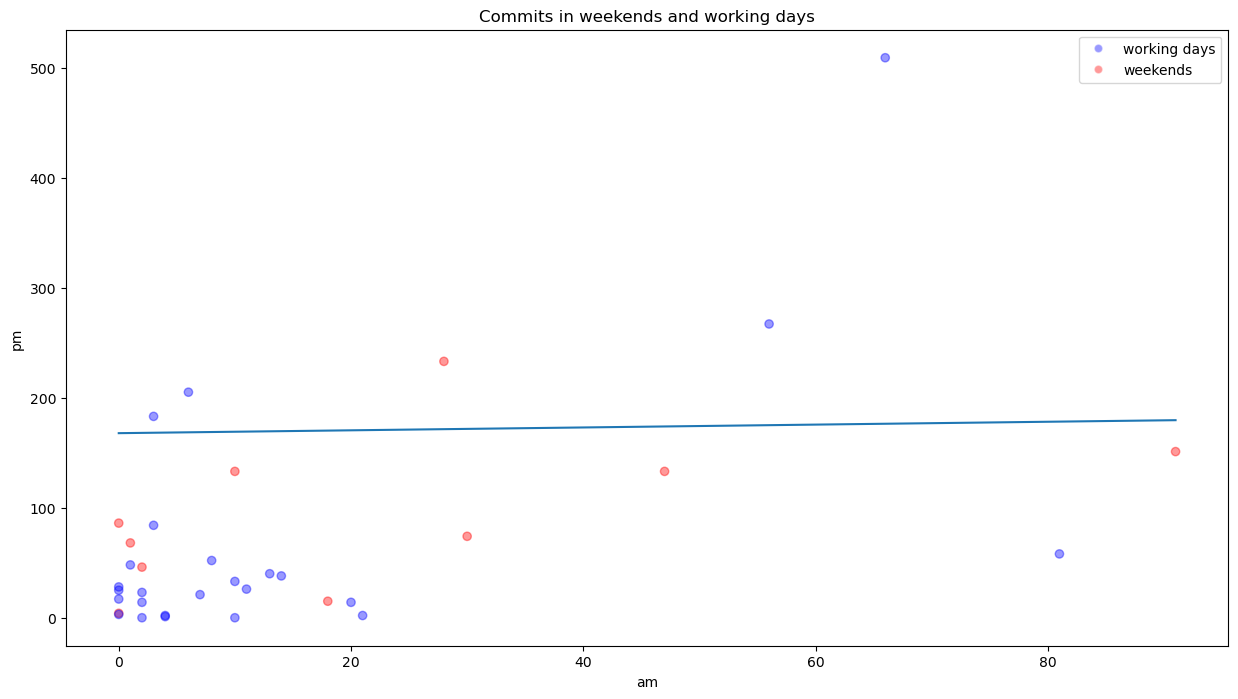

In [7]:
fig, ax = plt.subplots(figsize=(15, 8))
ax.scatter(x=df["am"], y=df["pm"], c = ["red" if x == "weekend" else "blue" for x in df["target"]], alpha=0.4)
ax.plot(x_line, y_line, label="decision boundary")
ax.set_xlabel("am")
ax.set_ylabel("pm")
ax.set_title("Commits in weekends and working days")

legend_elements = [Line2D([0], [0], marker = 'o', color='w', markerfacecolor='blue', label='working days', alpha=0.4),
                   Line2D([0], [0], marker = 'o', color='w', markerfacecolor='red', label='weekends', alpha=0.4)]

ax.legend(handles=legend_elements)
plt.show()

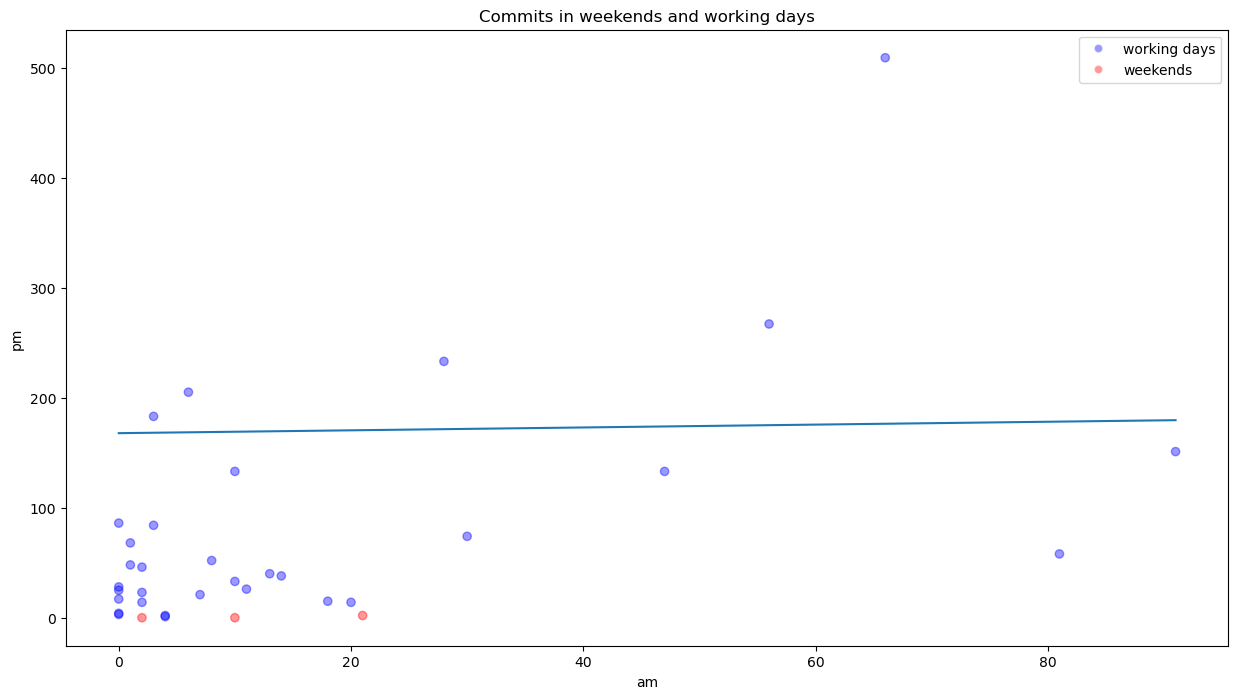

In [8]:
fig, ax = plt.subplots(figsize=(15, 8))
ax.scatter(x=df["am"], y=df["pm"], c = ["red" if x == "weekend" else "blue" for x in df["predict"]], alpha=0.4)
ax.plot(x_line, y_line, label="decision boundary")
ax.set_xlabel("am")
ax.set_ylabel("pm")
ax.set_title("Commits in weekends and working days")

legend_elements = [Line2D([0], [0], marker = 'o', color='w', markerfacecolor='blue', label='working days', alpha=0.4),
                   Line2D([0], [0], marker = 'o', color='w', markerfacecolor='red', label='weekends', alpha=0.4)]

ax.legend(handles=legend_elements)
plt.show()

В какой-то мере граница решений справилась - она отделила выходные

Посмотри как граница решений меняется от значения порога:

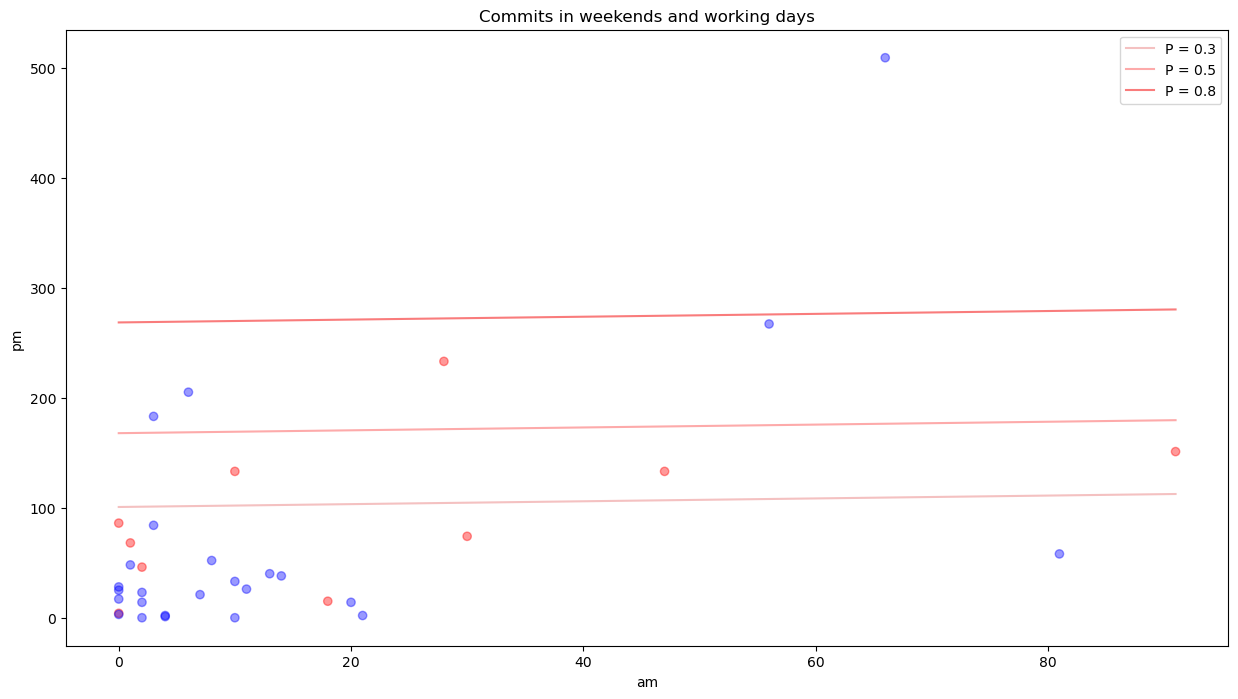

In [9]:
fig, ax = plt.subplots(figsize=(15, 8))
ax.scatter(x=df["am"], y=df["pm"], c = ["red" if x == "weekend" else "blue" for x in df["target"]], alpha=0.4)
ax.plot(x_line, find_x(x_line, reg.coef_, reg.intercept_, p=0.3), label="P = 0.3", color="#f4c1c1")
ax.plot(x_line, find_x(x_line, reg.coef_, reg.intercept_, p=0.5), label="P = 0.5", color="#fdaaaa")
ax.plot(x_line, find_x(x_line, reg.coef_, reg.intercept_, p=0.8), label="P = 0.8", color="#f97c7c")
ax.set_xlabel("am")
ax.set_ylabel("pm")
ax.set_title("Commits in weekends and working days")

ax.legend()
plt.show()

Видно, что чем вероятность выше, тем граница выше и лучше отделает x2 (weekends отмечены красным)

## 2. Standardizing and logreg

Linear models can be sensitive to the scale of your variables. You make it easier for them to find the optimal solution when you scale your features.

1. Apply `StandardScaler` to `X` and train logistic regression again with the same parameters.
2. Calculate `accuracy` for the new model. Did it get better than a naive classifier with the most popular class?
3. Draw the plots that were described above but for the new model.

_StandardScaler()_ will normalize the features i.e. each column of X, INDIVIDUALLY, so that each column/feature/variable will have μ = 0 and σ = 1.

### Обработка Х:

In [10]:
scaler = StandardScaler()
standart_X = pd.DataFrame(scaler.fit_transform(X), columns=["am", "pm"])

In [11]:
display(standart_X)

,am,pm
0,0.200690,-0.719904
1,-0.655914,-0.071822
2,0.072199,-0.592251
3,-0.613084,-0.513696
4,-0.698744,-0.494057
5,-0.698744,-0.464599
6,-0.270442,-0.415502
7,-0.613084,-0.602071
8,0.586162,-0.012906
9,0.500501,1.548382


In [12]:
standart_X.mean(axis=0)

am    4.758099e-17
pm   -2.379049e-17
dtype: float64

In [13]:
standart_X.std(axis=0)

am    1.014599
pm    1.014599
dtype: float64

### Обучение модели:

In [14]:
reg_standart = linear_model.LogisticRegression(random_state=21, fit_intercept=False)
reg_standart.fit(standart_X, Y)
df["predict_standart"] = reg_standart.predict(standart_X)

In [15]:
display(df)

,date,am,pm,target,predict,predict_standart
0,2020-04-17,21,2,working_day,weekend,working_day
1,2020-04-18,1,68,weekend,working_day,working_day
2,2020-04-19,18,15,weekend,working_day,working_day
3,2020-04-20,2,23,working_day,working_day,working_day
4,2020-04-21,0,25,working_day,working_day,working_day
5,2020-04-22,0,28,working_day,working_day,working_day
6,2020-04-23,10,33,working_day,working_day,working_day
7,2020-04-24,2,14,working_day,working_day,working_day
8,2020-04-25,30,74,weekend,working_day,weekend
9,2020-04-26,28,233,weekend,working_day,weekend


### Подсчет точности:

In [16]:
def get_accuracy(table, target_column : str, predict_column : str):
    accuracy = 0
    for index, row in table.iterrows():
        if row[target_column] == row[predict_column]:
            accuracy += 1

    accuracy /= len(df)
    return accuracy

In [17]:
print(get_accuracy(df, "target", "predict_standart"))

0.7428571428571429


### График для предсказаний

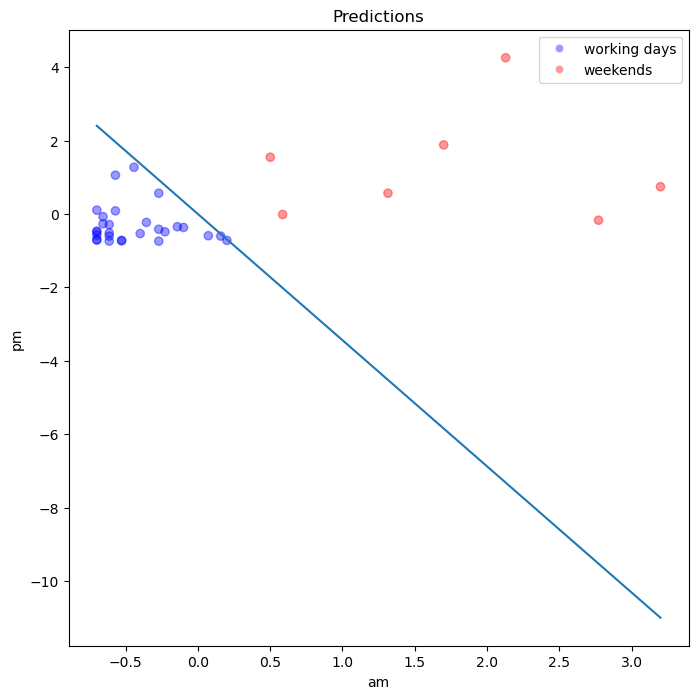

In [18]:
# x_line = np.linspace(min(standart_X["am"]), max(standart_X['am']), 100)
# y_line = find_x(x_line, reg_standart.coef_, reg_standart.intercept_, p=0.5)

a = -reg_standart.coef_[0][0] / reg_standart.coef_[0][1]
b = -reg_standart.intercept_[0] / reg_standart.coef_[0][1]
x_line = np.linspace(min(standart_X['am']), max(standart_X['am']))
y_line = a  * x_line + b

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(x=standart_X["am"], y=standart_X["pm"], c = ["red" if x == "weekend" else "blue" for x in df["predict_standart"]], alpha=0.4)
ax.plot(x_line, y_line, label="decision boundary")
ax.set_xlabel("am")
ax.set_ylabel("pm")
ax.set_title("Predictions")


legend_elements = [Line2D([0], [0], marker = 'o', color='w', markerfacecolor='blue', label='working days', alpha=0.4),
                   Line2D([0], [0], marker = 'o', color='w', markerfacecolor='red', label='weekends', alpha=0.4)]

ax.legend(handles=legend_elements)
plt.show()

### График для исходных данных

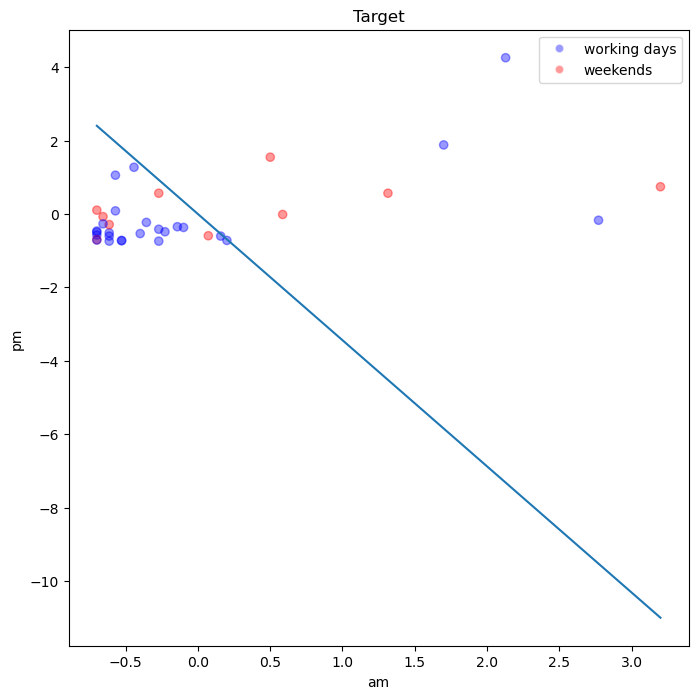

In [19]:
a = -reg_standart.coef_[0][0] / reg_standart.coef_[0][1]
b = -reg_standart.intercept_[0] / reg_standart.coef_[0][1]
x_line = np.linspace(min(standart_X['am']), max(standart_X['am']))
y_line = a  * x_line + b

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(x=standart_X["am"], y=standart_X["pm"], c = ["red" if x == "weekend" else "blue" for x in df["target"]], alpha=0.4)
ax.plot(x_line, y_line, label="decision boundary")
ax.set_xlabel("am")
ax.set_ylabel("pm")
ax.set_title("Target")


legend_elements = [Line2D([0], [0], marker = 'o', color='w', markerfacecolor='blue', label='working days', alpha=0.4),
                   Line2D([0], [0], marker = 'o', color='w', markerfacecolor='red', label='weekends', alpha=0.4)]

ax.legend(handles=legend_elements)
plt.show()

Как видно из графиков, нормализация облегчает задачу классификации в логистической регресии

## 3. SVM

1. Apply `SVC` model to the scaled dataframe using parameters `probability=True`, `random_state=21`.
2. Calculate `accuracy`.
3. Try different kernels, find the best in terms of accuracy.
4. Draw both plots again with the decisions boundary to see how this algorithm works.

SVC ищет гиперплоскость, которая максимально разделяет классы в пространстве признаков. Чем дальше эта плоскость от ближайших точек данных (опорных векторов), тем лучше модель.
SVC поддерживает различные функции ядра, такие как линейное, полиномиальное и радиальное базисное (RBF). Выбор ядра позволяет адаптировать модель к различным типам данных.


SVM алгоритм основан на концепции опорных векторов и работает, находя гиперплоскость, которая максимально разделяет классы в пространстве признаков.
_Опорные векторы_ - это точки данных, которые находятся ближе всего к разделяющей гиперплоскости. Они имеют наибольшее влияние на положение этой плоскости.
_Гиперплоскость_ - это обобщение понятия линии в двумерном пространстве и плоскости в трехмерном. SVM ищет гиперплоскость, которая максимально разделяет классы.

In [20]:
model = SVC(probability=True, random_state=21)
df_svc = standart_X.copy()
df_svc["target"] = df["target"]
X = df_svc[["am", "pm"]]
Y = df_svc.target

In [21]:
display(df_svc)

,am,pm,target
0,0.200690,-0.719904,working_day
1,-0.655914,-0.071822,weekend
2,0.072199,-0.592251,weekend
3,-0.613084,-0.513696,working_day
4,-0.698744,-0.494057,working_day
5,-0.698744,-0.464599,working_day
6,-0.270442,-0.415502,working_day
7,-0.613084,-0.602071,working_day
8,0.586162,-0.012906,weekend
9,0.500501,1.548382,weekend


### Анализ параметров

GridSearchCV используется для оптимизации гиперпараметров моделей машинного обучения. Он позволяет систематически перебирать заданные параметры и находить наилучшие комбинации для модели

In [22]:
kernels = {"kernel": ["linear", "poly", "rbf", "sigmoid"]}

Types of kernels:
* We use __Linear kernels__ when the number of features is large compared to the number of samples or when the data are linearly separable. Linear kernels’ suite for problems of text classification, document classification, and other high-dimensional data
k(x1,x2)=x1*x2
* The __RBF__ (Radial Basis Function Kernel) kernel is suitable for nonlinear problems and is the default choice for SVM. It’s powerful when there is no prior knowledge of the data, and we can capture complex relationships between data points
* __Polynomial__ kernels are useful when treating problems that show polynomial behavior. They are commonly used for computer vision and image recognition tasks
k(x1,x2)=(x1.x2+c)^d
* We use a __sigmoid__ kernel when dealing with neural network applications and when we know that the data distribution looks like a sigmoid function

In [23]:
grid_serach = GridSearchCV(estimator=model, param_grid=kernels, scoring="accuracy")
grid_serach.fit(X, Y)
print(grid_serach.best_params_)

{'kernel': 'poly'}


kernel = poly

In [24]:
model_poly = SVC(kernel="poly", probability=True, random_state=21)
svc =  model_poly.fit(X, Y)
df_svc["predict_poly"] = svc.predict(X)
print(get_accuracy(df_svc, "target", "predict_poly"))

0.7428571428571429


kernel = linear

In [25]:
model_linear = SVC(kernel="linear", probability=True, random_state=21)
svc =  model_linear.fit(X, Y)
df_svc["predict_linear"] = svc.predict(X)
print(get_accuracy(df_svc, "target", "predict_linear"))

0.7142857142857143


kernel = rbf

In [26]:
model_rbf = SVC(kernel="rbf", probability=True, random_state=21)
svc =  model_rbf.fit(X, Y)
df_svc["predict_rbf"] = svc.predict(X)
print(get_accuracy(df_svc, "target", "predict_rbf"))

0.7428571428571429


kernel = sigmoid

In [27]:
model_sigmoid = SVC(kernel="sigmoid", probability=True, random_state=21)
svc =  model_sigmoid.fit(X, Y)
df_svc["predict_sigmoid"] = svc.predict(X)
print(get_accuracy(df_svc, "target", "predict_sigmoid"))

0.6857142857142857


In [28]:
df_svc

,am,pm,target,predict_poly,predict_linear,predict_rbf,predict_sigmoid
0,0.200690,-0.719904,working_day,working_day,working_day,working_day,working_day
1,-0.655914,-0.071822,weekend,working_day,working_day,working_day,working_day
2,0.072199,-0.592251,weekend,working_day,working_day,working_day,working_day
3,-0.613084,-0.513696,working_day,working_day,working_day,working_day,working_day
4,-0.698744,-0.494057,working_day,working_day,working_day,working_day,working_day
5,-0.698744,-0.464599,working_day,working_day,working_day,working_day,working_day
6,-0.270442,-0.415502,working_day,working_day,working_day,working_day,working_day
7,-0.613084,-0.602071,working_day,working_day,working_day,working_day,working_day
8,0.586162,-0.012906,weekend,working_day,working_day,working_day,working_day
9,0.500501,1.548382,weekend,working_day,working_day,working_day,weekend


### График для предсказаний

/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


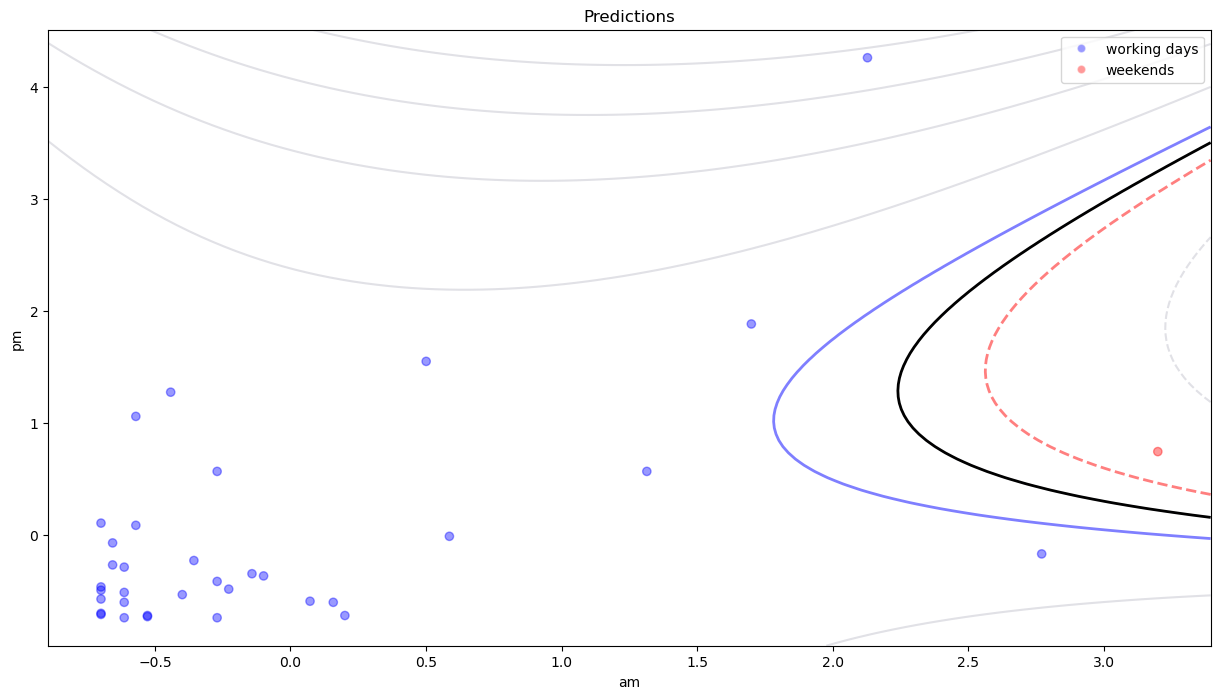

In [29]:
fig, ax = plt.subplots(figsize=(15, 8))
# рисуем точки
ax.scatter(x=df_svc["am"], y=df_svc["pm"], c = ["red" if x == "weekend" else "blue" for x in df_svc["predict_poly"]], alpha=0.4)
ax.set_xlabel("am")
ax.set_ylabel("pm")
ax.set_title("Predictions")

for model in [model_poly]:
    # сетка дней по абсцисе и ординате 
    x_start, x_finish = ax.get_xlim()
    y_start, y_finish = ax.get_ylim()
    x_line = np.linspace(x_start, x_finish, 100)
    y_line = np.linspace(y_start, y_finish, 100)
    # массив из x_line-ов и y_line-ов одной размерности
    xx, yy = np.meshgrid(x_line, y_line)
    # узлы функциии границы решений
    nodes = np.c_[xx.ravel(), yy.ravel()]
    Z = model_poly.decision_function(nodes)
    # нормализация границы решений под график
    Z = Z.reshape(xx.shape)
ax.contour(xx, yy, Z, colors="#696984", alpha = 0.2)
# Рисуем контур границы принятия решения - линии уровня при -0.5, 0, 0.5
ax.contour(xx, yy, Z, levels=[0], linewidths=2, colors='black')
ax.contour(xx, yy, Z, levels=[-0.5], linewidths=2, colors='red', alpha=0.5)
ax.contour(xx, yy, Z, levels=[0.5], linewidths=2, colors='blue', alpha=0.5)

ax.legend(handles=legend_elements)
plt.show()

Линии уровня функции границы решений можно видеть на диаграмме, то есть показывается как модель классифицирует: положительные значения указывают на один класс, а отрицательные — на другой. Черной линией уровня соответсвтует значение 0 - граница между классами.

Стоит отметить, что графически единственная точка другого класса (weekend) находится правее границы, а все синие точки - левее

Линии уровня C=-0.5 - это смещенная граница решений с большей вероятностью определения класса weekend. В свою очередь синяя линия - для класса working_day. Если обратиться к графику, можно увидеть, как область, ограниченная красным цветом, сузилась и множество красных точек стало более определенным, то же самое для синих точек.

### График для исходных данных

/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


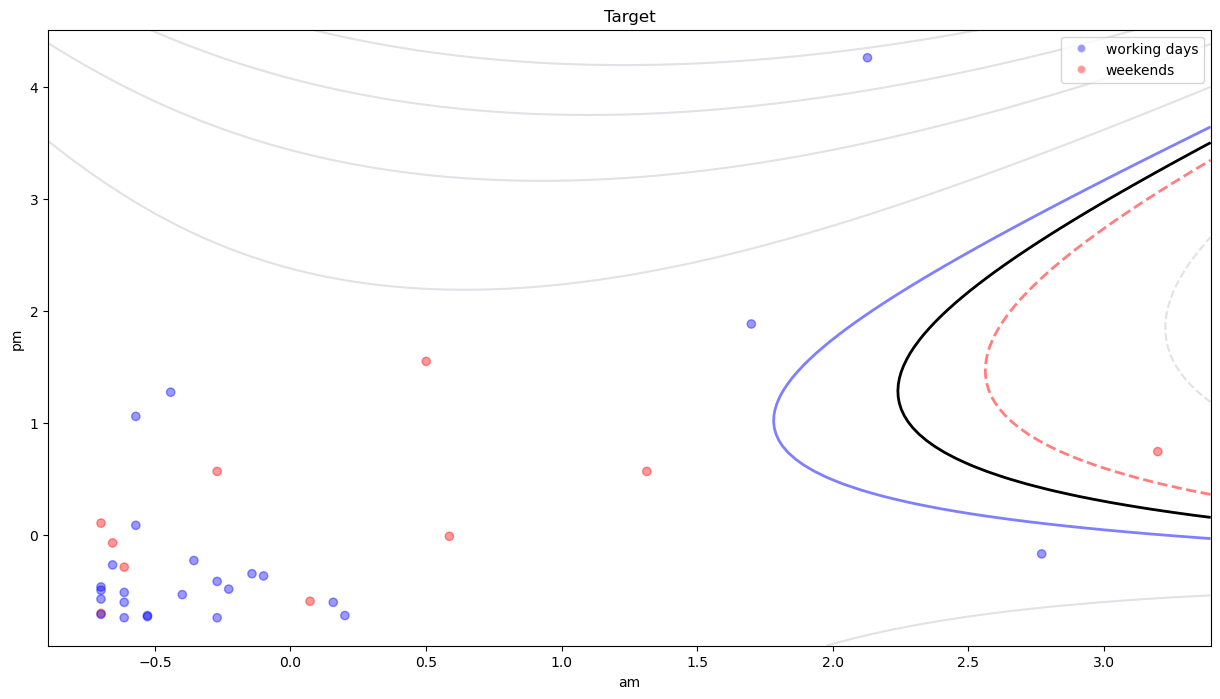

In [30]:
fig, ax = plt.subplots(figsize=(15, 8))
# рисуем точки
ax.scatter(x=df_svc["am"], y=df_svc["pm"], c = ["red" if x == "weekend" else "blue" for x in df_svc["target"]], alpha=0.4)
ax.set_xlabel("am")
ax.set_ylabel("pm")
ax.set_title("Target")

for model in [model_poly]:
    # сетка дней по абсцисе и ординате 
    x_start, x_finish = ax.get_xlim()
    y_start, y_finish = ax.get_ylim()
    x_line = np.linspace(x_start, x_finish, 100)
    y_line = np.linspace(y_start, y_finish, 100)
    # массив из x_line-ов и y_line-ов одной размерности
    xx, yy = np.meshgrid(x_line, y_line)
    # узлы функциии границы решений
    nodes = np.c_[xx.ravel(), yy.ravel()]
    Z = model_poly.decision_function(nodes)
    # нормализация границы решений под график
    Z = Z.reshape(xx.shape)
ax.contour(xx, yy, Z, colors="#696984", alpha=0.2)
# Рисуем контур границы принятия решения - линии уровня при 0
ax.contour(xx, yy, Z, levels=[0], linewidths=2, colors='black')
ax.contour(xx, yy, Z, levels=[-0.5], linewidths=2, colors='red', alpha=0.5)
ax.contour(xx, yy, Z, levels=[0.5], linewidths=2, colors='blue', alpha=0.5)

ax.legend(handles=legend_elements)
plt.show()

На исходных данных классификация работает неточно, так как предсказания модели не совсем верные

## 4. Decision tree

1. Apply `DecisionTreeClassifier` to the scaled dataframe using parameters `max_depth=4`, `random_state=42`.
2. Calculate accuracy.
3. Try different values of `max_depth`.
4. Draw both plots again with the decisions boundary to see how this algorithm works.
5. Using method `.plot_tree()` visualize the decision tree itself. It is another way of thinking about how the algorithm works.
6. How many leaves in the visualized tree label days as working days? Put your answer in the markdown cell in the end of the section.

In [31]:
df_tree = df.copy().drop(["predict", "predict_standart"], axis=1)
X = df[["am", "pm"]]
Y = df["target"]
display(df_tree)

,date,am,pm,target
0,2020-04-17,21,2,working_day
1,2020-04-18,1,68,weekend
2,2020-04-19,18,15,weekend
3,2020-04-20,2,23,working_day
4,2020-04-21,0,25,working_day
5,2020-04-22,0,28,working_day
6,2020-04-23,10,33,working_day
7,2020-04-24,2,14,working_day
8,2020-04-25,30,74,weekend
9,2020-04-26,28,233,weekend


In [32]:
clf = DecisionTreeClassifier(max_depth=4, random_state=42)
clf.fit(X, Y)
df_tree["predict"]= clf.predict(X)
display(df_tree)

,date,am,pm,target,predict
0,2020-04-17,21,2,working_day,working_day
1,2020-04-18,1,68,weekend,weekend
2,2020-04-19,18,15,weekend,working_day
3,2020-04-20,2,23,working_day,working_day
4,2020-04-21,0,25,working_day,working_day
5,2020-04-22,0,28,working_day,working_day
6,2020-04-23,10,33,working_day,working_day
7,2020-04-24,2,14,working_day,working_day
8,2020-04-25,30,74,weekend,weekend
9,2020-04-26,28,233,weekend,weekend


In [33]:
get_accuracy(table=df_tree, target_column="target", predict_column="predict")

0.9428571428571428

Проанализируем разные высоты дерева:

In [34]:
for h in range(1, 10):
    clf_1 = DecisionTreeClassifier(random_state=42, max_depth=h)
    clf_1.fit(X,Y)
    df_tree["pre"] = clf_1.predict(X)
    accuracy = get_accuracy(df_tree, "target", "pre")
    print(f"max_depth = {h}    accuracy = {accuracy}")
    if accuracy >= 1:
        break

df_tree.drop("pre", axis=1, inplace=True)

max_depth = 1    accuracy = 0.7714285714285715
max_depth = 2    accuracy = 0.8571428571428571
max_depth = 3    accuracy = 0.8857142857142857
max_depth = 4    accuracy = 0.9428571428571428
max_depth = 5    accuracy = 0.9714285714285714
max_depth = 6    accuracy = 1.0


Больше высоты 6 рассматривать бессмысленно, лучше результат на тестовой датафрейме не будет

In [35]:
df_tree

,date,am,pm,target,predict
0,2020-04-17,21,2,working_day,working_day
1,2020-04-18,1,68,weekend,weekend
2,2020-04-19,18,15,weekend,working_day
3,2020-04-20,2,23,working_day,working_day
4,2020-04-21,0,25,working_day,working_day
5,2020-04-22,0,28,working_day,working_day
6,2020-04-23,10,33,working_day,working_day
7,2020-04-24,2,14,working_day,working_day
8,2020-04-25,30,74,weekend,weekend
9,2020-04-26,28,233,weekend,weekend


### График для предсказаний

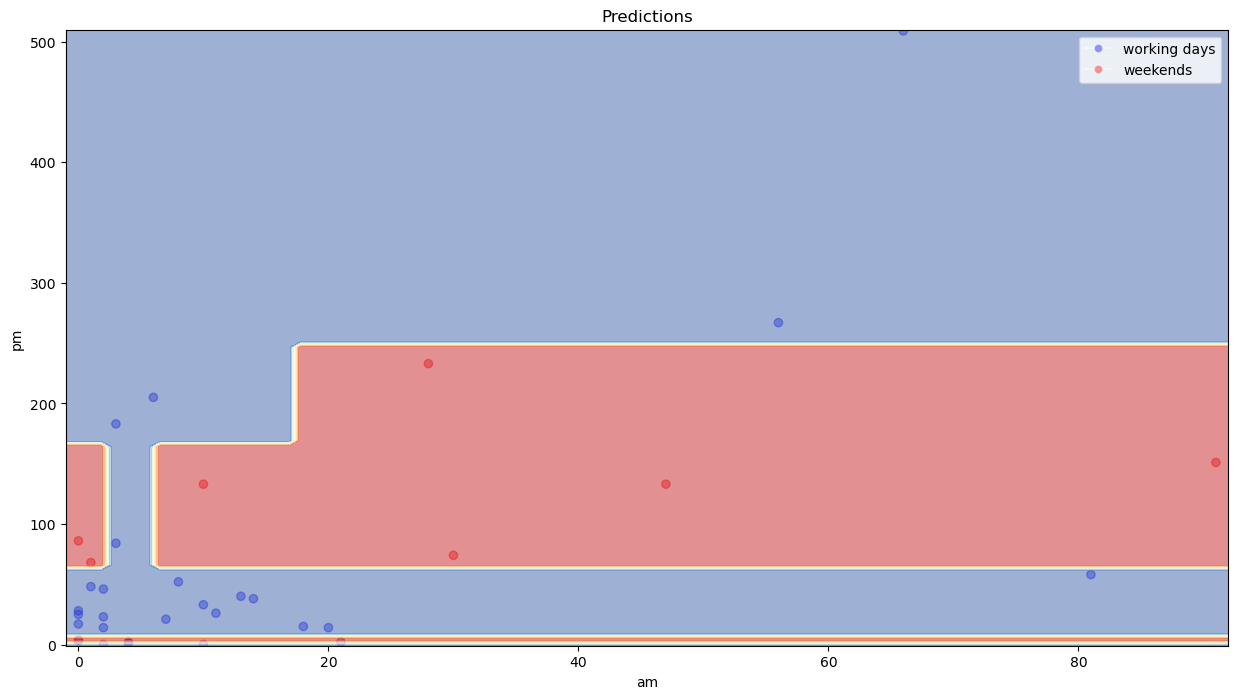

In [36]:
fig, ax = plt.subplots(figsize=(15, 8))
# рисуем точки
ax.scatter(x=df_tree["am"], y=df_tree["pm"], c = ["red" if x == "weekend" else "blue" for x in df_tree["predict"]], alpha=0.4)
ax.set_xlabel("am")
ax.set_ylabel("pm")
ax.set_title("Predictions")

for dec_tree in [clf]:
    dec_tree.fit(X, Y)
    # сетка дней по абсцисе и ординате 
    x_start, x_finish = ax.get_xlim()
    y_start, y_finish = ax.get_ylim()
    x_line = np.linspace(x_start, x_finish, 100)
    y_line = np.linspace(y_start, y_finish, 100)
    # массив из x_line-ов и y_line-ов одной размерности
    xx, yy = np.meshgrid(x_line, y_line)
    # узлы функциии границы решений
    nodes = np.c_[xx.ravel(), yy.ravel()]
    DecisionBoundaryDisplay.from_estimator(clf,X,
    cmap=plt.cm.RdYlBu,
    response_method="predict",
    ax=ax,
    alpha=0.5
)


ax.legend(handles=legend_elements)
plt.show()

### График для исходных данных

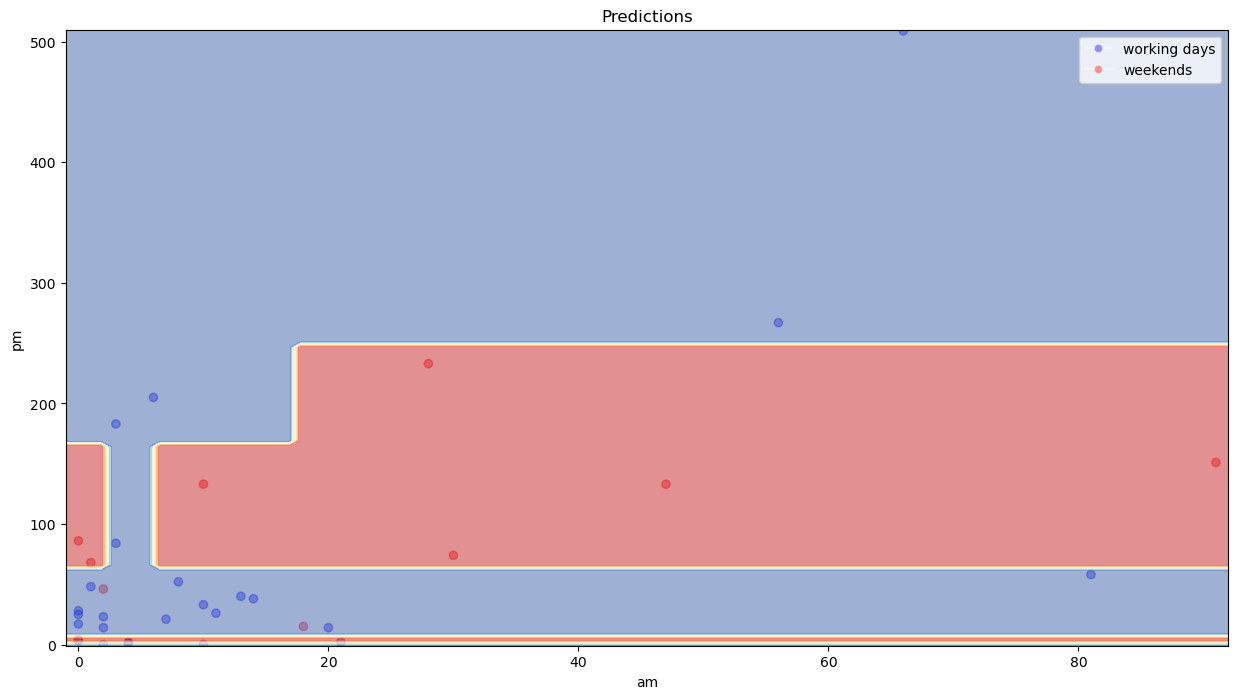

In [37]:
fig, ax = plt.subplots(figsize=(15, 8))
# рисуем точки
ax.scatter(x=df_tree["am"], y=df_tree["pm"], c = ["red" if x == "weekend" else "blue" for x in df_tree["target"]], alpha=0.4)
ax.set_xlabel("am")
ax.set_ylabel("pm")
ax.set_title("Predictions")

for dec_tree in [clf]:
    dec_tree.fit(X, Y)
    # сетка дней по абсцисе и ординате 
    x_start, x_finish = ax.get_xlim()
    y_start, y_finish = ax.get_ylim()
    x_line = np.linspace(x_start, x_finish, 100)
    y_line = np.linspace(y_start, y_finish, 100)
    # массив из x_line-ов и y_line-ов одной размерности
    xx, yy = np.meshgrid(x_line, y_line)
    # узлы функциии границы решений
    nodes = np.c_[xx.ravel(), yy.ravel()]
    DecisionBoundaryDisplay.from_estimator(clf,X,
    cmap=plt.cm.RdYlBu,
    response_method="predict",
    ax=ax,
    alpha=0.5
)


ax.legend(handles=legend_elements)
plt.show()

 Как видно из графика, дерево решений достаточно точно выполняет классификацию

### Визуализация дерева

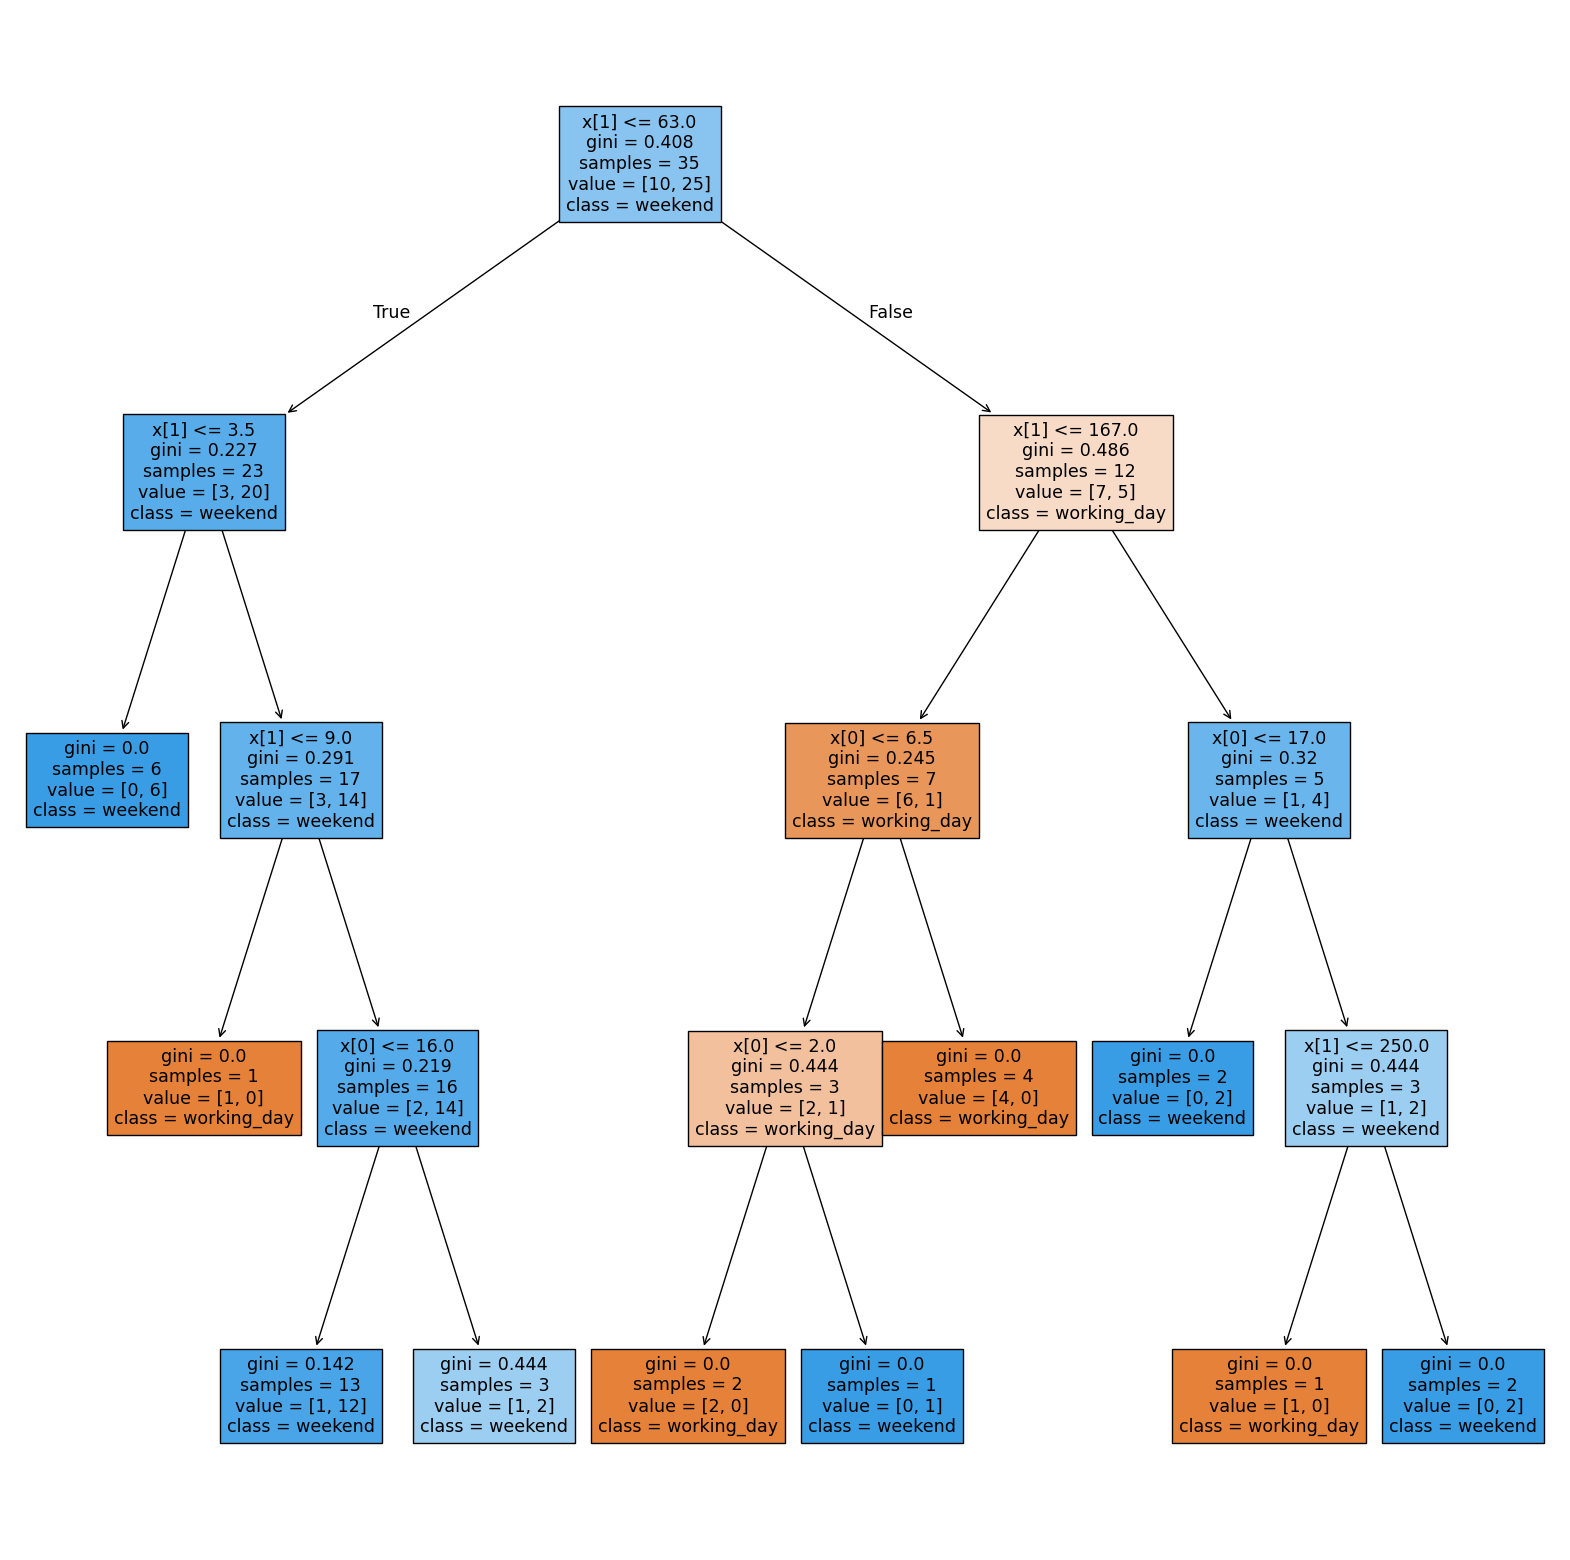

In [38]:
fig, ax = plt.subplots(figsize=(20, 20))
param_grid = {'max_depth': np.arange(4, 5)}
model = GridSearchCV(clf, param_grid, scoring='accuracy')
model.fit(X, Y)
plot_tree(model.best_estimator_,class_names=['working_day', 'weekend'], filled=True, ax=ax)
plt.show()

### How many leaves in the visualized tree label days as working days? - __4__